# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [11]:
 
def jacobi(A, b, e: float, max_iter=1000, verbose=True) -> np.ndarray: 
    
    A = np.array(A)
    b = np.array(b)
    n = len(A)
 
    erros = []
    x0 = np.zeros(n)
    x_new = np.zeros(n)
 
    for i in range(max_iter):
        x0 = x_new.copy()
 
        for j in range(n):
            soma = sum(A[j][k] * x0[k] for k in range(n) if k != j)
            x_new[j] = (b[j] - soma)*(1/A[j][j])
 
        erro = np.linalg.norm(x_new - x0)
        erros.append(erro)
 
        divergiu = False
        if np.isnan(erro) or np.isinf(erro):
            if verbose: print("Divergiu (overflow)")
            divergiu = True
            break
        
        a = 5
        if i >= a and all(erros[i-j] > erros[i-j-1] for j in range(a)):
            if verbose: print("Divergiu")
            divergiu = True
            break
        
        if erro < e:
            if verbose: print(f"Convergiu em {i+1} iterações")
            break
    else:
        if not divergiu:
            if verbose: print(f"Não convergiu dentro de {max_iter} iterações")
 
    residuo = np.linalg.norm(A @ x_new - b)
    if verbose: print(f"Resíduo: {residuo:.2e}")
 
    return erros
 
 
def jacobi_matricial(A, b, e: float, max_iter=1000, verbose=True):
    
    A = np.array(A)
    b = np.array(b)
    n = len(A)
 
    D = np.diag(A)
    L = np.tril(A, k=-1)
    U = np.triu(A, k=1)
    D_inv_vals = 1/D
    D_inv = np.diag(D_inv_vals)
    R = L + U
 
    erros = []
    x0 = np.zeros(n)
    x_new = np.zeros(n)
 
    for i in range(max_iter):
        x0 = x_new.copy()
 
        soma = b - (R @ x0)
        x_new = D_inv @ soma
 
        erro = np.linalg.norm(x_new - x0)
        erros.append(erro)
 
        divergiu = False
        if np.isnan(erro) or np.isinf(erro):
            if verbose: print("Divergiu (overflow)")
            divergiu = True
            break
        
        a = 5
        if i >= a and all(erros[i-j] > erros[i-j-1] for j in range(a)):
            if verbose: print("Divergiu")
            divergiu = True
            break
        
        if erro < e:
            if verbose: print(f"Convergiu em {i+1} iterações")
            break
    else:
        if not divergiu:
            if verbose: print(f"Não convergiu dentro de {max_iter} iterações")
 
    residuo = np.linalg.norm(A @ x_new - b)
    if verbose: print(f"Resíduo: {residuo:.2e}")
 
    return erros
 
 
def gauss_seidel(A, b, e: float, max_iter=1000, verbose=True):
 
    A = np.array(A)
    b = np.array(b)
    n = len(A)
 
    erros = []
    x0 = np.zeros(n)
    x_new = np.zeros(n)
 
    for i in range(max_iter):
        x0 = x_new.copy()
        
        for j in range(n):
            soma = sum(A[j][k] * x_new[k] for k in range(n) if k != j)
            x_new[j] = (b[j] - soma)*(1/A[j][j])
 
        erro = np.linalg.norm(x_new - x0)
        erros.append(erro)
 
        divergiu = False
        if np.isnan(erro) or np.isinf(erro):
            if verbose: print("Divergiu (overflow)")
            divergiu = True
            break
        
        a = 5
        if i >= a and all(erros[i-j] > erros[i-j-1] for j in range(a)):
            if verbose: print("Divergiu")
            divergiu = True
            break
        
        if erro < e:
            if verbose: print(f"Convergiu em {i+1} iterações")
            break
    else:
        if not divergiu:
            if verbose: print(f"Não convergiu dentro de {max_iter} iterações")
 
    residuo = np.linalg.norm(A @ x_new - b)
    if verbose: print(f"Resíduo: {residuo:.2e}")
 
    return erros


def gauss_seidel_matricial(A, b, e, max_iter=1000, verbose=True):

    A = np.array(A)
    b = np.array(b)
    n = len(A)
    
    D = np.diag(A)
    L = np.tril(A, k=-1)
    U = np.triu(A, k=1)
    
    erros = []
    x0 = np.zeros(n)
    x_new = np.zeros(n)
 
    for i in range(max_iter):
        x0 = x_new.copy()

        # produto matricial (ok)
        r = b - U @ x0
        
        # resolve (D+L)x = r (triangular inferior)
        for k in range(n):
            soma = L[k, :k] @ x_new[:k]   # produto vetorial (matricial!)
            x_new[k] = (r[k] - soma) / D[k]

 
        erro = np.linalg.norm(x_new - x0)
        erros.append(erro)
 
        divergiu = False
        if np.isnan(erro) or np.isinf(erro):
            if verbose: print("Divergiu (overflow)")
            divergiu = True
            break
        
        a = 5
        if i >= a and all(erros[i-j] > erros[i-j-1] for j in range(a)):
            if verbose: print("Divergiu")
            divergiu = True
            break
        
        if erro < e:
            if verbose: print(f"Convergiu em {i+1} iterações")
            break
    else:
        if not divergiu:
            if verbose: print(f"Não convergiu dentro de {max_iter} iterações")
 
    residuo = np.linalg.norm(A @ x_new - b)
    if verbose: print(f"Resíduo: {residuo:.2e}")
 
    return erros



Qual deveria ser a complexidade computacional do código que você escreveu?

Quebrando o cálculo da complexidade em funções:

i) `jacobi`: 
Note que a parte mais crítica seria o loop que calcula x_new, onde temos um loop externo: n e um loop interno(sum): n. Assim, o custo é de O(n²). As outras partes da função, como `np.linalg.norm` e `x_new.copy()` possuem complexidade O(n). 

Como o algoritmo é iterativo, a complexidade computacional da função `jacobi` é O(k*n²), onde k é a quantidade de iterações até convergir.


ii) `gauss_seidel`:
A função `gauss_seidel` é muito semelhante à jacobi, com a principal diferença estando na forma como o vetor x é atualizado (utilizando os valores já atualizados dentro da mesma iteração). A parte mais crítica continua sendo o cálculo de x_new, onde há um loop externo de tamanho n e, dentro dele, um somatório que também percorre até n elementos. Logo, essa etapa possui custo O(n²). As demais operações, como o cálculo da norma e a cópia de vetores, possuem custo linear O(n).

Como o algoritmo é iterativo, a complexidade da função gauss_seidel é O(k*n²), onde k é o número de iterações.

iii) jacobi_matricial:
A etapa mais custosa acontece no cálculo de R @ x0, que corresponde a uma multiplicação matriz-vetor, com custo de O(n²). Em seguida, tem outra multiplicação matriz-vetor (D_inv @ soma), também com custo O(n²). Assim, o custo total por iteração continua O(n²).
As outras operações, como cálculo da norma, cálculo do erro e a atualização de x possuem custo O(n), não mudando a ordem dominante.

Logo, a complexidade da função `jacobi_matricial` é O(k⋅n²), onde k é o número de iterações até convergência.

iv) `gauss_seidel_matricial`:
A princípio, o produto matriz-vetor `U @ x0` possui custo `O(n²)`. No loop da substituição direta, temos a linha `soma = L[i, :i] @ x[:i]`, que tem custo O(i), pra cada i. Somando pra i= 1 a n, temos que o custo total é O(n²).
As outras operações, como cálculo da norma, cálculo do erro e a atualização de x possuem custo O(n), não mudando a ordem dominante. 
Logo, a complexidade total da função `gauss_seidel_matricial` é O(k*n²), onde k é o número de iterações até convergência.



Dessa forma, a complexidade computacional do meu código é O(k*n²), onde k é o número de iterações até convergência.


_OBS:_ Note que o custo de calcular o resídulo `np.linalg.norm(A @ x - b)` custa O(n²), já que `np.linalg.norm` custa O(n) mas o produto `A @ x` pra uma matriz densa nxn custa O(n²), o que não altera o custo total de nenhuma das funções.

_OBS_: O uso do parâmetro bool na entrada das funções é para ser arbitrário dependendo da situação a plotagem dos gráficos (não é muito útil na letra (f), por exemplo)

## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

========== TAMANHO = 2 x 2 ==========
Jacobi:
Convergiu em 995 iterações
Resíduo: 0.00e+00
--------
Jacobi Matricial:
Convergiu em 995 iterações
Resíduo: 0.00e+00
--------
Gauss-Seidel:
Convergiu em 515 iterações
Resíduo: 0.00e+00
--------
Gauss-Seidel Matricial:
Convergiu em 515 iterações
Resíduo: 0.00e+00
--------
n=2: rho(Mj) = 0.9791
n=2: rho(Mgs) = 0.9586


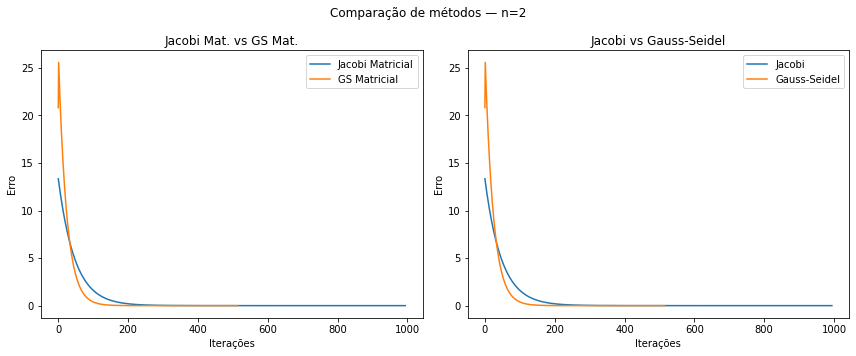

========== TAMANHO = 3 x 3 ==========
Jacobi:
Convergiu em 170 iterações
Resíduo: 7.16e-15
--------
Jacobi Matricial:
Convergiu em 170 iterações
Resíduo: 7.16e-15
--------
Gauss-Seidel:
Convergiu em 33 iterações
Resíduo: 7.16e-15
--------
Gauss-Seidel Matricial:
Convergiu em 33 iterações
Resíduo: 7.16e-15
--------
n=3: rho(Mj) = 0.8843
n=3: rho(Mgs) = 0.4994


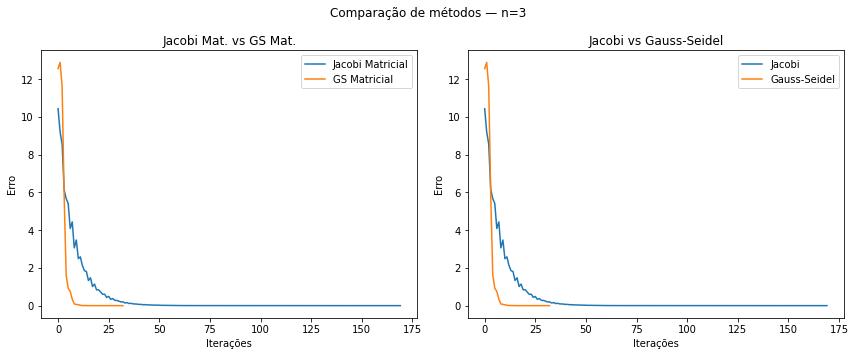

In [ ]:
def gerar_sistema_diag_dominante(n):
    # gera x
    x = [random.uniform(-10, 10) for _ in range(n)] 
    
    # monta matriz densa
    A = [[0.0]*n for _ in range(n)]
    for i in range(n): # acessa as linhas de A
        for j in range(n): # acessa as cols de A
            if i != j:
                A[i][j] = random.uniform(-10, 10)  # fora da diagonal
        
        # diag dominante
        soma_linha = sum(abs(A[i][j]) for j in range(n) if j != i)
        A[i][i] = soma_linha + random.uniform(0.1, 0.2) 

    # calcula b = Ax
    b = [0.0]*n 
    for i in range(n):
        for j in range(n):
            b[i] += A[i][j]*x[j]
    
    return A, b, x

def calcular_rho_mj(A):
    A = np.array(A)
    D = np.diag(np.diag(A))
    L = np.tril(A, k=-1)
    U = np.triu(A, k=1)
    Mj = -np.linalg.inv(D) @ (L + U)
    return max(abs(np.linalg.eigvals(Mj)))

def calcular_rho_mgs(A):
    A = np.array(A)
    D = np.diag(np.diag(A))
    L = np.tril(A, k=-1)
    U = np.triu(A, k=1)
    Mgs = -np.linalg.inv(D + L) @ U
    return max(abs(np.linalg.eigvals(Mgs)))
    


def testes(tamanhos, func) -> None:

    for n in tamanhos:
        A, b, x_sol = func(n)
        A_np = np.array(A)
        b_np = np.array(b)

        print(f'========== TAMANHO = {n} x {n} ==========')
        # gerar funçoẽs
        print("Jacobi:")
        erros_j = jacobi(A_np, b_np, x_sol, 1e-8)
        print("-"*8)
        print("Jacobi Matricial:")
        erros_j_mat = jacobi_matricial(A_np, b_np, x_sol, 1e-8)
        print("-"*8)
        print("Gauss-Seidel:")
        erros_gs = gauss_seidel(A_np, b_np, x_sol, 1e-8)
        print("-"*8)
        print("Gauss-Seidel Matricial:")
        erros_gs_mat = gauss_seidel_matricial(A_np, b_np, x_sol, 1e-8)
        print("-"*8)

        print(f"n={n}: rho(Mj) = {calcular_rho_mj(A):.4f}")
        print(f"n={n}: rho(Mgs) = {calcular_rho_mgs(A):.4f}")
        
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f"Comparação de métodos — n={n}")

        # Jacobi vs Gauss-Seidel
        axs[1].plot(erros_j, label="Jacobi")
        axs[1].plot(erros_gs, label="Gauss-Seidel")
        axs[1].set_title("Jacobi vs Gauss-Seidel")
        axs[1].set_xlabel("Iterações")
        axs[1].set_ylabel("Erro")
        axs[1].legend()

        # Jacobi matricial vs Gauss-Seidel matricial
        axs[0].plot(erros_j_mat, label="Jacobi Matricial")
        axs[0].plot(erros_gs_mat, label="GS Matricial")
        axs[0].set_title("Jacobi Mat. vs GS Mat.")
        axs[0].set_xlabel("Iterações")
        axs[0].set_ylabel("Erro")
        axs[0].legend()


        plt.tight_layout()
        plt.show()



tamanhos = [2, 3]

testes(tamanhos, gerar_sistema_diag_dominante)


Os elementos fora da diagonal de A foram gerados aleatoriamente em `[−10, 10]`, garantindo variabilidade sem instabilidade numérica. A diagonal principal foi definida como a soma dos valores absolutos dos demais elementos da linha somada com uma constante `C ∈ [0.1, 1]`, garantindo a dominância diagonal estrita (propriedade suficiente para a convergência dos dois métodos).


Além disso, quando construimos o vetor `b` como o produto `b=Ax`, onde x é um vetor gerado aleatoriamente, conseguimos garantir que o sistema linear tem uma solução conhecida. Isso permite verificar a convergência dos métodos e avaliar sua precisão de uma forma mais controlada.

Relembrando novamente que a função `gerar_sistema_diag_dominante` foi criada apenas para gerar os testes e observar a convergência de uma forma clara. 

É nítido que Gauss-Seidel converge mais rapidamente que Jacobi, as suas curvas de erro caem de forma mais brusca no início, enquanto Jacobi apresenta uma queda mais gradual. Isso ocorre porque GS utiliza os valores mais recentes disponíveis a cada iteração, o que propaga as correções de forma mais rápida. As curvas de Jacobi tem uma queda mais suave, mas as curvas de GS caem de forma mais brusca no início. 

Para C pequeno, os dois métodos convergem mais lentamente, já que `A[i][i]` fica só um pouco maior que a soma da linha. Quando C é grande, temos que os dois métodos convergem rapidamente, o que faz a diferença de Gauss Seidel e Jacobi "sumir".

O raio espectral (máximo do valor absoluto dos autovalores de Mj) `ρ(M)` controla como o erro se propaga a cada iteração. Quando o `ρ(M)` é próximo de 1, o erro cai muito devagar, então são necessárias muitas iterações para os métodos convergirem. Observando empiricamente, temos que `ρ(Mgs)` < `ρ(Mj)` em boa parte das matrizes, o que reforça novamente que o método de Jacobi converge mais lentamente que o método de Gauss-Seidel.

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

========== TAMANHO = 4 x 4 ==========
Jacobi:
Divergiu
Resíduo: 1.99e-15
--------
Jacobi Matricial:
Divergiu
Resíduo: 1.99e-15
--------
Gauss-Seidel:
Divergiu
Resíduo: 1.99e-15
--------
Gauss-Seidel Matricial:
Divergiu
Resíduo: 1.99e-15
--------
n=4: rho(Mj) = 2.2473
n=4: rho(Mgs) = 1.2834


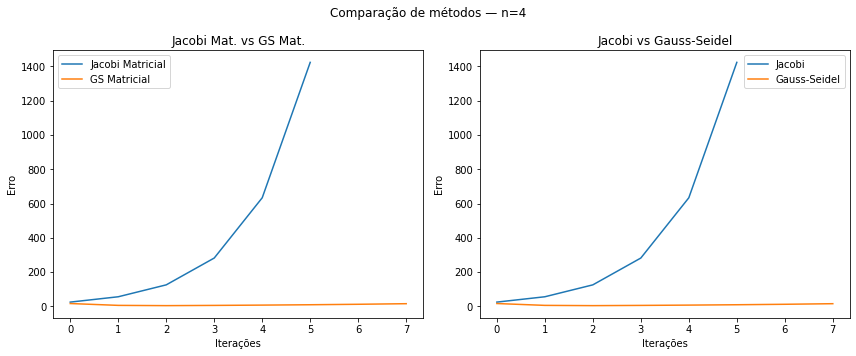

========== TAMANHO = 16 x 16 ==========
Jacobi:
Divergiu
Resíduo: 9.40e-15
--------
Jacobi Matricial:
Divergiu
Resíduo: 9.40e-15
--------
Gauss-Seidel:
Divergiu
Resíduo: 9.40e-15
--------
Gauss-Seidel Matricial:
Divergiu
Resíduo: 9.40e-15
--------
n=16: rho(Mj) = 21.2872
n=16: rho(Mgs) = 260.2007


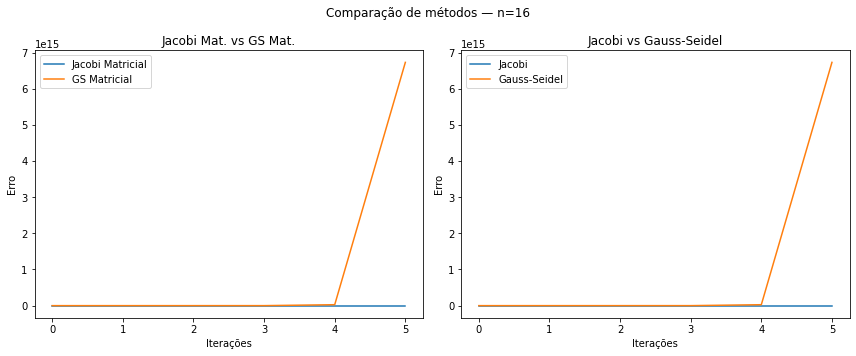

========== TAMANHO = 64 x 64 ==========
Jacobi:
Divergiu
Resíduo: 1.81e-13
--------
Jacobi Matricial:
Divergiu
Resíduo: 1.81e-13
--------
Gauss-Seidel:
Divergiu
Resíduo: 1.81e-13
--------
Gauss-Seidel Matricial:
Divergiu
Resíduo: 1.81e-13
--------
n=64: rho(Mj) = 302.0414
n=64: rho(Mgs) = 38489568793800.8359


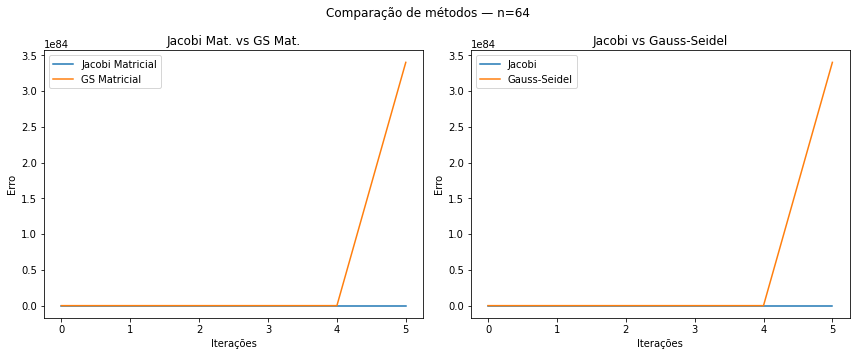

========== TAMANHO = 256 x 256 ==========
Jacobi:
Divergiu
Resíduo: 3.09e-12
--------
Jacobi Matricial:
Divergiu
Resíduo: 3.09e-12
--------
Gauss-Seidel:
Divergiu (overflow)
Resíduo: 3.09e-12
--------
Gauss-Seidel Matricial:
Divergiu (overflow)
Resíduo: 3.09e-12
--------
n=256: rho(Mj) = 844.7181
n=256: rho(Mgs) = 63332830609946072.0000


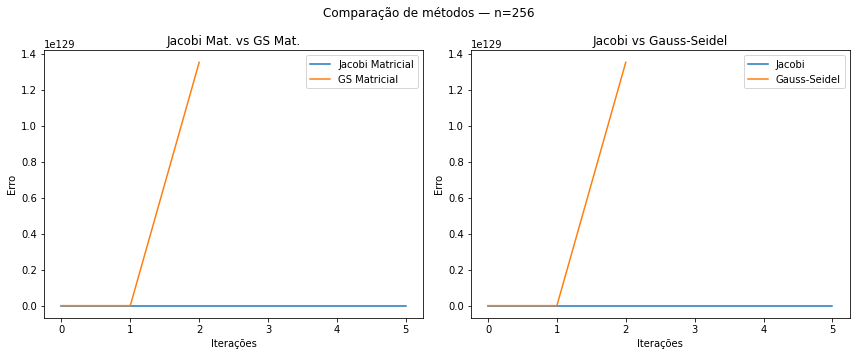

========== TAMANHO = 512 x 512 ==========
Jacobi:
Divergiu
Resíduo: 1.15e-11
--------
Jacobi Matricial:
Divergiu
Resíduo: 1.15e-11
--------
Gauss-Seidel:
Divergiu (overflow)
Resíduo: 1.15e-11
--------
Gauss-Seidel Matricial:
Divergiu (overflow)
Resíduo: 1.15e-11
--------
n=512: rho(Mj) = 1354.9550
n=512: rho(Mgs) = 11861900610320666.0000


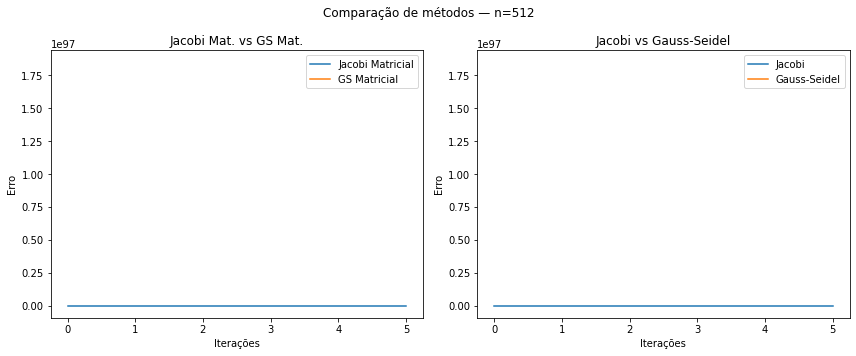

In [ ]:
def gerar_sistema(n):
    # gera x
    x = [random.uniform(1, 5) for _ in range(n)]

    # monta matriz
    A = np.random.rand(n,n)

    # calcula b = Ax
    b = [0]*n
    for i in range(n):
        for j in range(n):
            b[i] += A[i][j]*x[j]

    return A, b, x


tamanhos = [4, 16, 64, 256, 512]

testes(tamanhos, gerar_sistema)

Ao criar matriz do tipo `rand(m,m)`, não conseguimos garantir a dominância diagonal da matriz. Sem essa garantia, os métodos podem não convergir. Isso signfica que ao calcular ambos os algoritmos, o erro não tende a zero ao longo das iterações, podendo inclusive crescer ou oscilar, o que indica divergência do método para esse tipo de matriz.


Existe a possibilidade de matrizes do tipo `rand(m,m)` que satisfaçam as condições de convergência, mas não é esperado que isso não ocorra. 


A convergência desses métodos depende do raio espectral (máximo do valor absoluto dos autovalores) da matriz de iteração associada. Em particular, o método converge se `ρ(M)<1` e diverge se `ρ(M)>1`. Para matrizes aleatórias, não temos a garantia de que essa condição seja satisfeita, o que explica o comportamento observado empiricamente.

Quando a matriz não satisfaz as condições de convergência, as dependências entre variáveis de Gauss-Seidel “amplificam erros”, i.e., propagam erro mais rápido (porque usa valores atualizados). Isso pode fazer com que `ρ(Mgs) >> ρ(Mj)`, como podemos observar.

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?


===== m = 5 =====
m=5, k=0.00, taxa=0.02
m=5, k=0.30, taxa=0.01
m=5, k=0.60, taxa=0.01
m=5, k=0.90, taxa=0.00
m=5, k=1.20, taxa=0.09
m=5, k=1.50, taxa=0.14
m=5, k=1.80, taxa=0.28
m=5, k=2.10, taxa=0.35
m=5, k=2.40, taxa=0.53
m=5, k=2.70, taxa=0.74
m=5, k=3.00, taxa=0.85
m=5, k=3.30, taxa=0.95
k_jacobi ≈ 3.2999999999999994
m=5, k=0.00, taxa=0.01
m=5, k=0.30, taxa=0.01
m=5, k=0.60, taxa=0.03
m=5, k=0.90, taxa=0.02
m=5, k=1.20, taxa=0.11
m=5, k=1.50, taxa=0.21
m=5, k=1.80, taxa=0.33
m=5, k=2.10, taxa=0.51
m=5, k=2.40, taxa=0.75
m=5, k=2.70, taxa=0.71
m=5, k=3.00, taxa=0.89
m=5, k=3.30, taxa=0.92
m=5, k=3.60, taxa=0.99
k_gs ≈ 3.599999999999999

===== m = 10 =====
m=10, k=0.00, taxa=0.00
m=10, k=0.30, taxa=0.00
m=10, k=0.60, taxa=0.00
m=10, k=0.90, taxa=0.00
m=10, k=1.20, taxa=0.00
m=10, k=1.50, taxa=0.00
m=10, k=1.80, taxa=0.00
m=10, k=2.10, taxa=0.00
m=10, k=2.40, taxa=0.02
m=10, k=2.70, taxa=0.07
m=10, k=3.00, taxa=0.29
m=10, k=3.30, taxa=0.28
m=10, k=3.60, taxa=0.60
m=10, k=3.90, taxa=

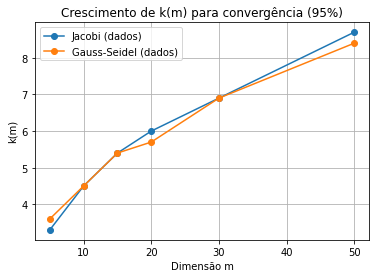

In [23]:
def convergiu_metodo(metodo, A, b, tol=1e-8, max_iter=1000): #verifica se a matriz converge p determinado metodo
    erros = metodo(A, b, tol, max_iter, verbose=False)
    
    if len(erros) == 0:
        return False
    
    # convergiu se último erro < tol
    return erros[-1] < tol

def gerar_A(m, k):
    A = np.random.randn(m, m)
    A += k * np.eye(m)
    return A


def taxa_convergencia(m, k, metodo, N=100): 
    #dado o k, conta a qtt de vezes que converge/total de testes(N)
    count = 0
    
    for _ in range(N):
        A = gerar_A(m, k)
        x_real = np.random.randn(m)
        b = A @ x_real
        
        if convergiu_metodo(metodo, A, b):
            count += 1
    
    return count / N

def encontrar_k(m, metodo, alvo=0.95, N=100):
    k = 0.0
    passo = 0.3
    
    while True:
        taxa = taxa_convergencia(m, k, metodo, N)
        print(f"m={m}, k={k:.2f}, taxa={taxa:.2f}")
        
        if taxa >= alvo:
            return k
        
        k += passo

ms = [5, 10, 15, 20, 30, 50]
ks_jacobi = []
ks_gs = []

for m in ms:
    print(f"\n===== m = {m} =====")
    
    k_j = encontrar_k(m, jacobi)
    print(f"k_jacobi ≈ {k_j}")
    ks_jacobi.append(k_j)

    
    k_gs = encontrar_k(m, gauss_seidel)
    print(f"k_gs ≈ {k_gs}")
    ks_gs.append(k_gs)


# dados
ms = np.array(ms)
ks_jacobi = np.array(ks_jacobi)
ks_gs = np.array(ks_gs)

# ajuste linear (reta)
coef_j = np.polyfit(ms, ks_jacobi, 1)
coef_gs = np.polyfit(ms, ks_gs, 1)

reta_j = np.poly1d(coef_j)
reta_gs = np.poly1d(coef_gs)

# gráfico
plt.figure()

plt.plot(ms, ks_jacobi, marker='o', label='Jacobi (dados)')
plt.plot(ms, ks_gs, marker='o', label='Gauss-Seidel (dados)')


plt.xlabel("Dimensão m")
plt.ylabel("k(m)")
plt.title("Crescimento de k(m) para convergência (95%)")

plt.legend()
plt.grid()

plt.show()

(Comentários)

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

Ao impor que `ρ(MJ)<ρ(Mgs)`, garantimos que o método de Jacobi vai ter uma taxa de convergência superior à do método de Gauss-Seidel. Isso acontece pois o raio espectral está diretamente relacionado à velocidade de decaimento do erro ao longo das iterações (quanto menor o valor de `ρ(M)`, o erro tende a zero mais rápido).

Dizer que um método possui “melhor convergência” significa que ele atinge a solução com menor número de iterações, e não necessariamente que produz uma solução mais precisa. No experimento realizado, isso é representado no fato de que o método de Jacobi converge em menos iterações do que o método de Gauss-Seidel.

Note que não necessariamente a diferença de iterações entre os métodos é grande, o que faz com que a taxa de decaimento do erro seja muito parecida nos dois métodos. Por isso, temos que as curvas no gráfico apresentam comportamentos quase idênticos. 

========== TAMANHO = 4 x 4 ==========
Jacobi:
Convergiu em 71 iterações
Resíduo: 0.00e+00
--------
Jacobi Matricial:
Convergiu em 71 iterações
Resíduo: 0.00e+00
--------
Gauss-Seidel:
Convergiu em 133 iterações
Resíduo: 0.00e+00
--------
Gauss-Seidel Matricial:
Convergiu em 133 iterações
Resíduo: 0.00e+00
--------
n=4: rho(Mj) = 0.7357
n=4: rho(Mgs) = 0.8472


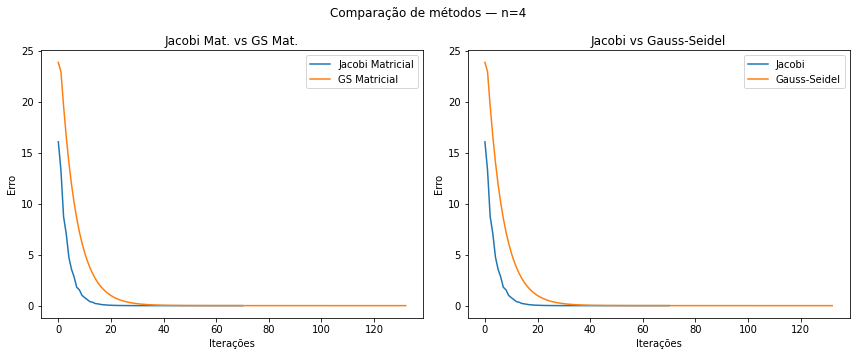

(71, 71, 133, 133)

In [90]:
def filtro(n):
    while True:
        A, b, x = gerar_sistema_diag_dominante(n)
        rho_mj = calcular_rho_mj(A)
        rho_mgs = calcular_rho_mgs(A)
        if rho_mj < rho_mgs:
            return A


def teste_filtro(A, n, verbose=True) :
    x_real = np.array([random.uniform(-10, 10) for _ in range(4)])
    b = A @ x_real
    A_np = np.array(A)
    b_np = np.array(b)


    print(f'========== TAMANHO = {n} x {n} ==========')
    # gerar funçoẽs
    print("Jacobi:")
    erros_j = jacobi(A_np, b_np, x_real, 1e-8)
    iteracoes_j = len(erros_j)
    print("-"*8)
    print("Jacobi Matricial:")
    erros_j_mat = jacobi_matricial(A_np, b_np, x_real, 1e-8)
    iteracoes_j_mat = len(erros_j_mat)
    print("-"*8)
    print("Gauss-Seidel:")
    erros_gs = gauss_seidel(A_np, b_np, x_real, 1e-8)
    iteracoes_gs = len(erros_gs)
    print("-"*8)
    print("Gauss-Seidel Matricial:")
    erros_gs_mat = gauss_seidel_matricial(A_np, b_np, x_real, 1e-8)
    iteracoes_gs_mat = len(erros_gs_mat)
    print("-"*8)
    print(f"n={n}: rho(Mj) = {calcular_rho_mj(A):.4f}")
    print(f"n={n}: rho(Mgs) = {calcular_rho_mgs(A):.4f}")

    if verbose:

        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f"Comparação de métodos — n={n}")
        # Jacobi vs Gauss-Seidel
        axs[1].plot(erros_j, label="Jacobi")
        axs[1].plot(erros_gs, label="Gauss-Seidel")
        axs[1].set_title("Jacobi vs Gauss-Seidel")
        axs[1].set_xlabel("Iterações")
        axs[1].set_ylabel("Erro")
        axs[1].legend()
        # Jacobi matricial vs Gauss-Seidel matricial
        axs[0].plot(erros_j_mat, label="Jacobi Matricial")
        axs[0].plot(erros_gs_mat, label="GS Matricial")
        axs[0].set_title("Jacobi Mat. vs GS Mat.")
        axs[0].set_xlabel("Iterações")
        axs[0].set_ylabel("Erro")
        axs[0].legend()


        plt.tight_layout()
        plt.show()


    return iteracoes_j, iteracoes_j_mat, iteracoes_gs, iteracoes_gs_mat


A = filtro(4)
teste_filtro(A, 4, verbose=True)

## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à $A$? O que acontece se esta perturbação acontecer apenas fora da diagonal?

Matriz                         | It. Jacobi |   It. GS   |  ρ(Mj)   |  ρ(Mgs)  | Jacobi mais rápido? 
----------------------------------------------------------------------------------------------------
Original                       |     67     |    128     |  0.7357  |  0.8472  |         Sim         
----------------------------------------------------------------------------------------------------
Perturbada fora ε=0.01         |     70     |    106     |  0.7361  |  0.8483  |         Sim         
Perturbada fora ε=0.1          |     73     |    135     |  0.7436  |  0.8592  |         Sim         
Perturbada fora ε=1.0          |     53     |     91     |  0.6740  |  0.8136  |         Sim         
Perturbada fora ε=5.0          |     75     |     88     |  0.7490  |  0.7785  |         Sim         
========== TAMANHO = 4 x 4 ==========
Jacobi:
Convergiu em 69 iterações
Resíduo: 0.00e+00
--------
Jacobi Matricial:
Convergiu em 69 iterações
Resíduo: 0.00e+00
--------
Gauss-Seidel:
Co

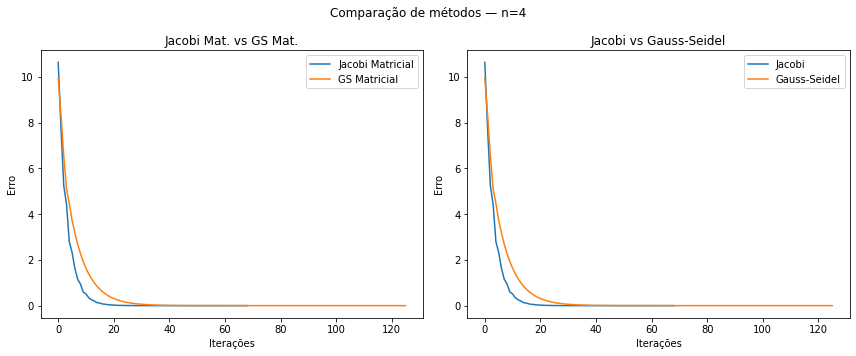

========== TAMANHO = 4 x 4 ==========
Jacobi:
Convergiu em 75 iterações
Resíduo: 0.00e+00
--------
Jacobi Matricial:
Convergiu em 75 iterações
Resíduo: 0.00e+00
--------
Gauss-Seidel:
Convergiu em 86 iterações
Resíduo: 0.00e+00
--------
Gauss-Seidel Matricial:
Convergiu em 86 iterações
Resíduo: 0.00e+00
--------
n=4: rho(Mj) = 0.7490
n=4: rho(Mgs) = 0.7785


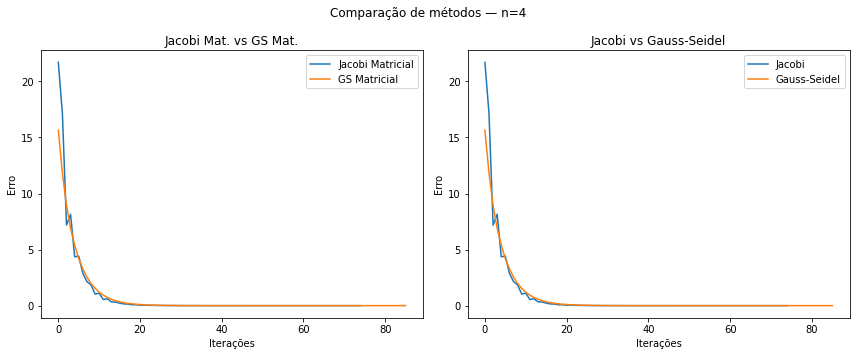

(75, 75, 86, 86)

In [94]:
def calcular_metricas(A, n):
    x_real = np.array([random.uniform(-10, 10) for _ in range(n)])
    b = A @ x_real
    A_np = np.array(A)
    b_np = np.array(b)
    erros_j  = jacobi(A_np, b_np, x_real, 1e-8, verbose=False)
    erros_gs = gauss_seidel(A_np, b_np, x_real, 1e-8, verbose=False)
    return len(erros_j), len(erros_gs)


escalas = [0.01, 0.1, 1.0, 5.0]

# original
it_j, it_gs = calcular_metricas(A, 4)
rho_j = calcular_rho_mj(A)
rho_gs = calcular_rho_mgs(A)
mais_rapido = "Sim" if it_j < it_gs else "Não"

print(f"{'Matriz':<30} | {'It. Jacobi':^10} | {'It. GS':^10} | {'ρ(Mj)':^8} | {'ρ(Mgs)':^8} | {'Jacobi mais rápido?':^20}")
print("-" * 100)
print(f"{'Original':<30} | {it_j:^10} | {it_gs:^10} | {rho_j:^8.4f} | {rho_gs:^8.4f} | {mais_rapido:^20}")
print("-" * 100)

for escala in escalas:
    epsilon_fora = [[0.0]*4 for _ in range(4)]
    for i in range(4):
        for j in range(4):
            if i != j:
                epsilon_fora[i][j] = random.uniform(-escala, escala)
    A_fora = A + np.array(epsilon_fora)
    
    it_j_f, it_gs_f = calcular_metricas(A_fora, 4)
    rho_j_f = calcular_rho_mj(A_fora)
    rho_gs_f = calcular_rho_mgs(A_fora)
    mais_rapido = "Sim" if it_j_f < it_gs_f else "Não"
    label = f"Perturbada fora ε={escala}"
    print(f"{label:<30} | {it_j_f:^10} | {it_gs_f:^10} | {rho_j_f:^8.4f} | {rho_gs_f:^8.4f} | {mais_rapido:^20}")

# plota só o original e o mais perturbado
teste_filtro(A, 4)
teste_filtro(A + np.array(epsilon_fora), 4)

É observado que perturbações pequenas aplicadas apenas aos elementos fora da diagonal não alteram muito o comportamento dos métodos. Em todos os casos analisados, o método de Jacobi se mantém mais rápido que o de Gauss-Seidel, o que é consistente com o fato de que ρ(Mj)<ρ(Mgs) em todas as instâncias.

Além disso, percebemos que os valores dos raios espectrais vão sofrer apenas variações moderadas, indicando que a estrutura principal da matriz (em especial a dominância diagonal) foi preservada mesmo depois das perturbações. Como consequência, o número de iterações também não apresenta mudanças muito drásticas, permanecendo na mesma ordem de grandeza.

Por outro lado, para perturbações maiores (como ε=1.0 e ε=5.0), podemos observar um comportamento menos previsível no número de iterações. Em particular, tem casos em que os dois métodos convergem mais rapidamente, o que nos sugere que a perturbação pode, ocasionalmente, reduzir o raio espectral das matrizes de iteração.

Resumindo, os resultados indicam que os métodos são relativamente robustos a pequenas perturbações fora da diagonal, e que a relação entre os raios espectrais continua sendo um bom indicador da velocidade de convergência, mesmo após modificações na matriz.